In [103]:

import sys
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density


data = np.load("../../../_recordings/2024-06-23--20-55-08_with-all-integers/archive.npz")



results = {}

for experiment in data.keys():
    experiment_parameters = data[experiment]["reboot_seed"]["experiment_parameters"][0]
    shape = experiment_parameters["shape"]

    if shape[0] in results:
        results[shape[0]].append(data[experiment])
    else:
        results[shape[0]] = [data[experiment]]

z_order = 7
roots_of_unity = np.array([[np.cos(2 * np.pi * i / z_order),
                                np.sin(2 * np.pi * i / z_order)] for i in range(z_order)])



lattice_sizes = []

result_keys = list(results.keys())
result_keys.sort()


time_series = {}
tin_data = {}
pp_correlators = {}
average_plaquettes = {}
pp_corr_differences = {}
average_plaquette_integer = {}

for shape in result_keys:
    results[shape].sort(key=lambda x: x["reboot_seed"]["experiment_parameters"]["beta"])

    print(shape)
    for res in results[shape]:
        print(res.dtype)


    results[shape] = np.array(results[shape])

    

    rec_shape = results[shape]["ploop_corr_recordings"]["polyakov_loops"].shape

    _,_,number_rec, x_dim, y_dim, z_dim = rec_shape


    loops = results[shape]["ploop_corr_recordings"]["polyakov_loops"]
    loops = roots_of_unity[loops]

    # Tin Data
    temp = loops.sum(axis=(3,4,5))
    tin_snapshot = np.linalg.norm(temp, axis=-1)  
    tin_snapshot = tin_snapshot.sum(axis=(1,2))/(number_rec*x_dim*y_dim*z_dim)
    tin_data[x_dim]= tin_snapshot

    # Time series
    time_serie = loops.sum(axis=(3,4,5)).squeeze(axis=1)/(x_dim*y_dim*z_dim)
    time_series[x_dim] = time_serie

    betas = results[shape]["reboot_seed"]["experiment_parameters"]["beta"].squeeze()

    lattice_sizes.append(x_dim)

    pp_correlators[x_dim] = results[shape]["ploop_corr_recordings"]["pp_correlators"]
    average_plaquettes[x_dim] = results[shape]["ploop_corr_recordings"]["average_plaquette"]
    pp_corr_differences[x_dim] = results[shape]["ploop_corr_recordings"]["pp_correlators_differences"]
    average_plaquette_integer[x_dim] = results[shape]["ploop_corr_recordings"]["average_plaquette_integer"]

 


# save the data
np.savez("temp/treated_data_integer", time_series=time_series, tin_data=tin_data, betas=betas, lattice_sizes=lattice_sizes, pp_correlators=pp_correlators, average_plaquettes=average_plaquettes, pp_corr_differences=pp_corr_differences, average_plaquette_integer=average_plaquette_integer)
    



6
[('reboot_seed', [('last_state', [('edges', 'u1', (5184,)), ('rng_gen', [('rng_gen_wrapper', 'u1', (16,))]), ('performed_updates', '<u8'), ('accepted_updates', '<u8')]), ('experiment_parameters', [('shape', '<u4', (4,)), ('z_order', '<u4'), ('beta', '<f4'), ('lambda', '<f4'), ('rng_seed', '<u8')])]), ('run_info', [('recordings', '<u4'), ('recording_skip', '<u4'), ('recordings_until_backup', '<u4'), ('backup_number', '<u4'), ('recording_time', '<i8'), ('run_id', '<u4')]), ('ploop_corr_recordings', [('polyakov_loops', 'u1', (80000, 6, 6, 6)), ('polyakov_loop_correlators', '<f4', (80000, 7, 2)), ('pp_correlators', '<f4', (80000, 7, 2)), ('average_plaquette', '<f4', (80000, 2)), ('pp_correlators_differences', '<u8', (80000, 7, 7)), ('average_plaquette_integer', '<u8', (80000, 7))])]
[('reboot_seed', [('last_state', [('edges', 'u1', (5184,)), ('rng_gen', [('rng_gen_wrapper', 'u1', (16,))]), ('performed_updates', '<u8'), ('accepted_updates', '<u8')]), ('experiment_parameters', [('shape', '

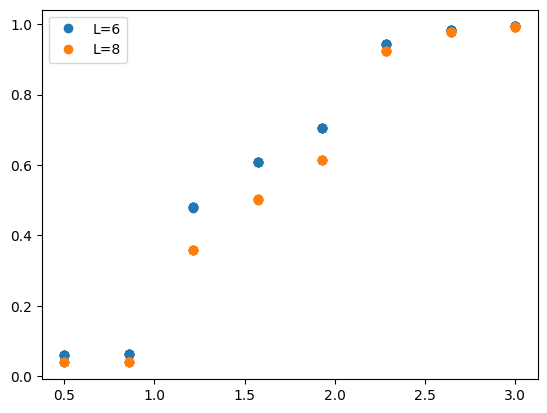

In [96]:
data = np.load("temp/treated_data_integer.npz", allow_pickle=True)

tin_data = data["tin_data"].item()
betas = data["betas"]

fig, ax = plt.subplots()

for key in tin_data.keys():
    ax.plot(betas, tin_data[key], 'o', label=f"L={key}")

ax.legend()
plt.show()


6 (40, 80000, 2)
8 (40, 15000, 2)


/Users/landa/Documents/GitHub/crunchy/myenv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/landa/Documents/GitHub/crunchy/myenv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


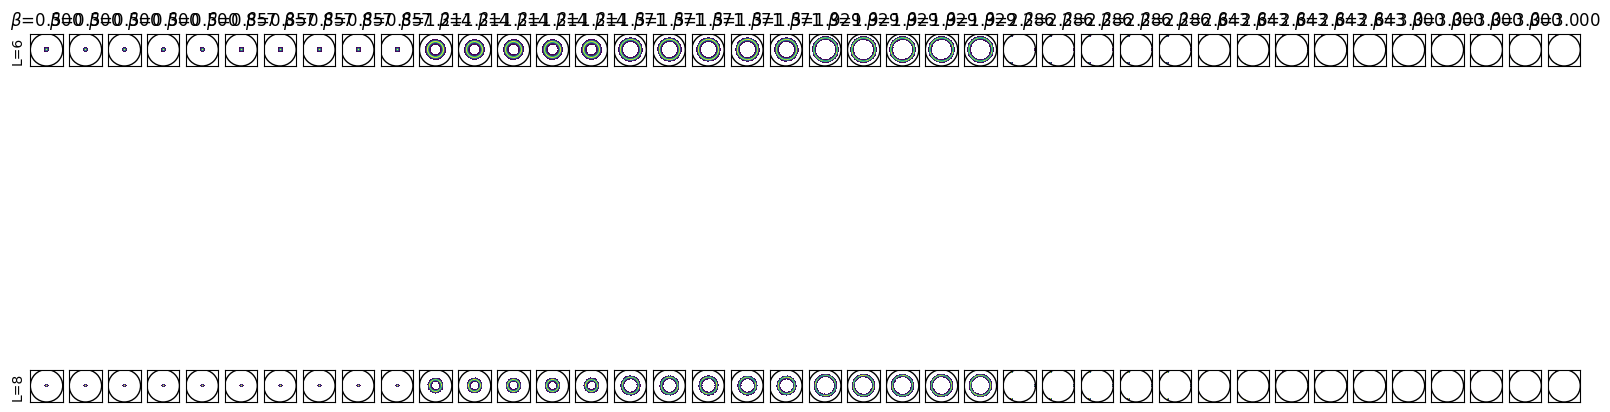

In [97]:

data = np.load("temp/treated_data_integer.npz", allow_pickle=True)

time_series = data["time_series"].item()

betas = data["betas"]


for key in time_series.keys():
    print(key, time_series[key].shape)

# Give number of keys in the dictionary
num_lattice_sizes = len(time_series.keys())


rows = num_lattice_sizes
columns = len(betas)


fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(rows, columns)

axes = []

white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

# for i in range(rows):
for (i, key) in enumerate(time_series.keys()):
    for j in range(columns):
        time_serie = time_series[key][j]
        time_serie_rotated = time_serie.copy()
        rotation_matrix = np.array([[np.cos(2 * np.pi / 3), -np.sin(2 * np.pi / 3)], [
                                    np.sin(2 * np.pi / 3), np.cos(2 * np.pi / 3)]])

        time_serie_rotated = np.dot(time_serie, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        time_serie_rotated = np.dot(time_serie_rotated, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        x = time_serie[:, 0]
        y = time_serie[:, 1]

        radius = 1

        axes.append(fig.add_subplot(
            gs[i, j], projection='scatter_density'))

        axes[-1].set_xlim(-radius, radius)
        axes[-1].set_ylim(-radius, radius)

        axes[-1].scatter_density(x, y, cmap=white_viridis, dpi=200)

        axes[-1].set_xlim(-radius, radius)
        axes[-1].set_ylim(-radius, radius)

        axes[-1].set_aspect('equal', 'box')
        axes[-1].set_xticks([])
        axes[-1].set_yticks([])
        # axes[-1].set_title(f"{index}")
        circle = plt.Circle((0, 0), 1, color='black', fill=False)
        axes[-1].add_artist(circle)


for i in range(columns):
    axes[i].set_title(r"$\beta$={:.3f}".format(
        betas[i]))

# Add title to rows
for i in range(rows):
    axes[i*columns].set_ylabel(f"L={lattice_sizes[i]}")

plt.show()


(40, 1, 80000, 7, 2)
(40, 1, 15000, 9, 2)


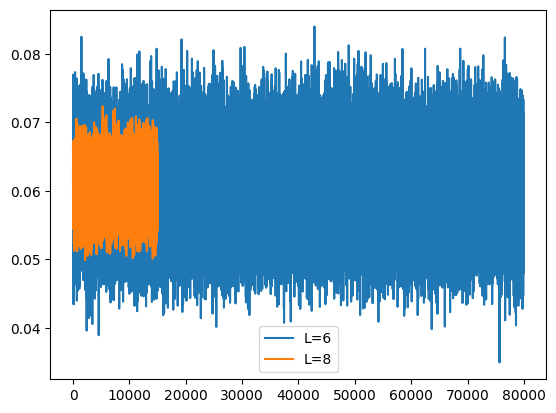

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

data = np.load("temp/treated_data_integer.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()

fig = plt.figure()

which_beta = 3

# Use colormap viridis to color the lines according to the lattice size
cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=6, vmax=16)



for key in pp_correlators.keys():
    print(pp_correlators[key].shape)

    pp_correlator = pp_correlators[key][which_beta,:,...].squeeze(axis=0)

    lattice_size = 2
    time_series = pp_correlator

    time_series = time_series[:,lattice_size,0]

    time_series = time_series[1:]

    xs = np.arange(len(time_series))

    color = cmap(norm(key))

    plt.plot(xs[1:], time_series[1:], '-', label=f"L={key}")

plt.legend()
plt.show()


[0.5        0.5        0.5        0.5        0.5        0.85714287
 0.85714287 0.85714287 0.85714287 0.85714287 1.2142857  1.2142857
 1.2142857  1.2142857  1.2142857  1.5714285  1.5714285  1.5714285
 1.5714285  1.5714285  1.9285715  1.9285715  1.9285715  1.9285715
 1.9285715  2.2857144  2.2857144  2.2857144  2.2857144  2.2857144
 2.642857   2.642857   2.642857   2.642857   2.642857   3.
 3.         3.         3.         3.        ]
1.5392550121506865e-05
2.140695922570046e-05
1.2945120702489987e-05
1.1791865501042942e-05
1.750815946999218e-05
0.00010575738955487246
0.00010893729101224547
0.00010982353723321125
0.00010497550868426853
0.00010611738465116094


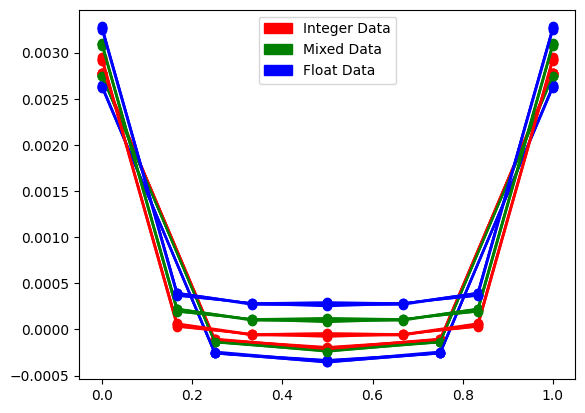

In [162]:

data = np.load("temp/treated_data_integer.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()
average_plaquettes = data["average_plaquettes"].item()
betas = data["betas"]
pp_corr_differences = data["pp_corr_differences"].item()
average_plaquette_integer = data["average_plaquette_integer"].item()

print(betas)


fig = plt.figure()



# Use colormap viridis to color the lines according to the lattice size
cmap = plt.get_cmap('viridis')
norm = Normalize(vmin=0, vmax=len(pp_correlators.keys()))


which_beta = 2



for (i,key) in enumerate(pp_correlators.keys()):

    # if key != 6:
    #     continue

    for beta in range(5*which_beta, 5*(which_beta+1)):
        pp_correlator = pp_correlators[key][beta,:,...].squeeze(axis=0)
        average_plaquette = average_plaquettes[key][beta,:,...].squeeze(axis=0)

        color = cmap(norm(i))

        thermalise = 0

        pp_correlator_mean = pp_correlator[thermalise:].mean(axis=0)[:]
        average_plaquette_mean = average_plaquette[thermalise:].mean(axis=0)


        pp_correlator_mean = pp_correlator_mean[:,0]
        average_plaquette_mean = average_plaquette_mean[0]

    
    

        cutoff = 1
        if cutoff > 0:
            pp_correlator_mean = pp_correlator_mean[cutoff:-cutoff]
        else: 
            pp_correlator_mean = pp_correlator_mean




        pp_correlator_mean = pp_correlator_mean - average_plaquette_mean**2

        Ls = np.arange(len(pp_correlator_mean))
        max_L = np.max(Ls)
        Ls = Ls / max_L

        

        variance = pp_correlator.var(axis=0)[:,0]
        variance = variance[cutoff:-cutoff]
        std = np.sqrt(variance/len(pp_correlator))


        differences = pp_corr_differences[key][beta,...].squeeze()
        differences = differences.sum(axis=0)
        exponential_map = np.array([[np.cos(2*np.pi*i/7), np.sin(2*np.pi*i/7)] for i in range(7)])


        distance_correlators = []
        for i in range(0, len(differences)):
            total_correlators = sum(differences[i,:])
            corr = np.array([0.0,0.0])
            for j in range(0, len(differences[i])):
                corr += differences[i,j]*exponential_map[j]
            distance_correlators.append(corr/total_correlators)

        


        average_p_integer = average_plaquette_integer[key][beta,...].squeeze()
        average_p_integer = average_p_integer.sum(axis=0)
        total_average_integer = average_p_integer.sum(axis=0)

        res_average_p_integer = np.array([0.0,0.0])
        for j in range(0, len(average_p_integer)):
            res_average_p_integer += average_p_integer[j]*exponential_map[j]
        
        res_average_p_integer = res_average_p_integer/total_average_integer

        print(abs(res_average_p_integer[0] - average_plaquette_mean))

        integer_correlators = np.array(distance_correlators)[:,0][cutoff:-cutoff] - res_average_p_integer[0]**2      
        

        mixed_precision = np.array(distance_correlators)[:,0][cutoff:-cutoff] - average_plaquette_mean**2
        # 
        plt.plot(Ls, integer_correlators, '-o', color='red')

        # plt.plot(0.5, integer_correlators[len(integer_correlators)//2], 'o', color='red')

        plt.plot(Ls, mixed_precision, '-o', color='green')
        plt.plot(Ls, pp_correlator_mean, '-o', color='blue')
        


    

import matplotlib.patches as mpatches

red_patch = mpatches.Patch(color='red', label='Integer Data')
green_patch = mpatches.Patch(color='green', label='Mixed Data')
blue_patch = mpatches.Patch(color='blue', label='Float Data')
plt.legend(handles=[red_patch, green_patch, blue_patch])




plt.show()


In [108]:
data = np.load("temp/treated_data_integer.npz", allow_pickle=True)
pp_correlators = data["pp_correlators"].item()
average_plaquettes = data["average_plaquettes"].item()
betas = data["betas"]
pp_corr_differences = data["pp_corr_differences"].item()

lattice_size = 6

beta = 36

# differences = pp_corr_differences[lattice_size][beta,...].squeeze()
# differences = differences.sum(axis=0)
# exponential_map = np.array([[np.cos(2*np.pi*i/7), np.sin(2*np.pi*i/7)] for i in range(7)])


# distance_correlators = []
# for i in range(0, len(differences)):
#     total_correlators = sum(differences[i,:])
#     corr = np.array([0.0,0.0])
#     for j in range(0, len(differences[i])):
#         corr += differences[i,j]*exponential_map[j]
#     distance_correlators.append(corr/total_correlators)

ZORDER = 7

exponential_map = np.array([[np.cos(2*np.pi*i/ZORDER), np.sin(2*np.pi*i/ZORDER)] for i in range(ZORDER)])


average_plaquette_integer = data["average_plaquette_integer"].item()
average_plaquette_integer = average_plaquette_integer[lattice_size][beta,...].squeeze()
average_plaquette_integer = average_plaquette_integer.sum(axis=0)

total_average_plaquette = average_plaquette_integer.sum(axis=0)
average_plaquette = np.array([0.0,0.0])

for j in range(0, len(average_plaquette_integer)):
    average_plaquette += average_plaquette_integer[j]*exponential_map[j]

average_plaquette = average_plaquette/total_average_plaquette





622080000
